# Nepal Earthquake Building Damage Prediction
## Predicting Severe Damage in Ramechhap District (2015 Gorkha Earthquake)

**Overview**  
The 2015 Gorkha earthquake in Nepal was one of the most devastating disasters in the country’s modern history, destroying or damaging hundreds of thousands of buildings and claiming nearly 9,000 lives. 
This project uses real post-disaster survey data collected by Kathmandu Living Labs and Nepal’s Central Bureau of Statistics to build a classification model that predicts whether a building suffered severe damage.
By focusing on Ramechhap district (one of the heavily affected areas), the model can help governments, NGOs, and insurance companies prioritize retrofitting, allocate reconstruction funds more fairly, and improve future building codes in earthquake-prone regions.

**Data source:** Raw train_values.csv + train_labels.csv from DrivenData (public competition data, ~260k buildings) - https://www.drivendata.org/competitions/57/nepal-earthquake/data/.

**ETL step:** a local SQLite relational database from scratch (two tables: building_features and building_damage) using Python + sqlite3.

**SQL skills:** Joins, schema exploration, filtered queries.

**Wrangling:** Leakage audit (none in raw data), multicollinearity check, high-cardinality handling, binary target engineering (severe_damage = damage_grade 3).

**Model:** Logistic Regression + OneHotEncoder pipeline.

**Evaluation:** Accuracy + odds-ratio interpretation.

---

In [13]:
# Imports
import sqlite3
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

warnings.simplefilter(action="ignore", category=FutureWarning)
sns.set_style("whitegrid")
%matplotlib inline

## 1: Building SQLite Database from Raw CSVs (ETL)

In [3]:
# Create and populate the SQLite database
conn = sqlite3.connect("nepal_earthquake.db")

# Load raw CSVs (assumes files are in the same folder as the notebook)
train_values = pd.read_csv("train_values.csv")
train_labels = pd.read_csv("train_labels.csv")

# Create tables
train_values.to_sql("building_features", conn, if_exists="replace", index=False)
train_labels.to_sql("building_damage", conn, if_exists="replace", index=False)

print("Database created successfully!")
print("Tables:", pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn))

Database created successfully!
Tables:                 name
0  building_features
1    building_damage


In [7]:
# Explore schema 
# List all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in the database:")
print(tables)

# Preview building_features
print("\nFirst 5 rows of building_features:")
print(pd.read_sql("SELECT * FROM building_features LIMIT 5;", conn))

# Preview building_damage
print("\nFirst 5 rows of building_damage:")
print(pd.read_sql("SELECT * FROM building_damage LIMIT 5;", conn))

conn.close()

Tables in the database:
                name
0  building_features
1    building_damage

First 5 rows of building_features:
   building_id  geo_level_1_id  geo_level_2_id  geo_level_3_id  \
0       802906               6             487           12198   
1        28830               8             900            2812   
2        94947              21             363            8973   
3       590882              22             418           10694   
4       201944              11             131            1488   

   count_floors_pre_eq  age  area_percentage  height_percentage  \
0                    2   30                6                  5   
1                    2   10                8                  7   
2                    2   10                5                  5   
3                    2   10                6                  5   
4                    3   30                8                  9   

  land_surface_condition foundation_type  ... has_secondary_use_agriculture  

## 2: Data Wrangling with SQL + Pandas

In [8]:
# Create wrangle function
def wrangle(db_path):
    conn = sqlite3.connect(db_path)
    
    query = """
        SELECT f.*, d.damage_grade
        FROM building_features f
        JOIN building_damage d ON f.building_id = d.building_id
    """
    df = pd.read_sql(query, conn, index_col="building_id")
        
    # Create binary target (DrivenData uses 1-2-3 scale; 3 = severe)
    df["severe_damage"] = (df["damage_grade"] == 3).astype(int)
    df.drop(columns=["damage_grade"], inplace=True)
    
    # Drop multicollinear feature
    df.drop(columns=["count_floors_pre_eq"], inplace=True)
    
    return df

df = wrangle("nepal_earthquake.db")
print(df.shape)
df.head()

(260601, 38)


,geo_level_1_id,geo_level_2_id,geo_level_3_id,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,severe_damage
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6,487,12198,30,6,5,t,r,n,f,...,0,0,0,0,0,0,0,0,0,1
28830,8,900,2812,10,8,7,o,r,n,x,...,0,0,0,0,0,0,0,0,0,0
94947,21,363,8973,10,5,5,t,r,n,f,...,0,0,0,0,0,0,0,0,0,1
590882,22,418,10694,10,6,5,t,r,n,f,...,0,0,0,0,0,0,0,0,0,0
201944,11,131,1488,30,8,9,t,r,n,f,...,0,0,0,0,0,0,0,0,0,1


## 3: Exploratory Data Analysis

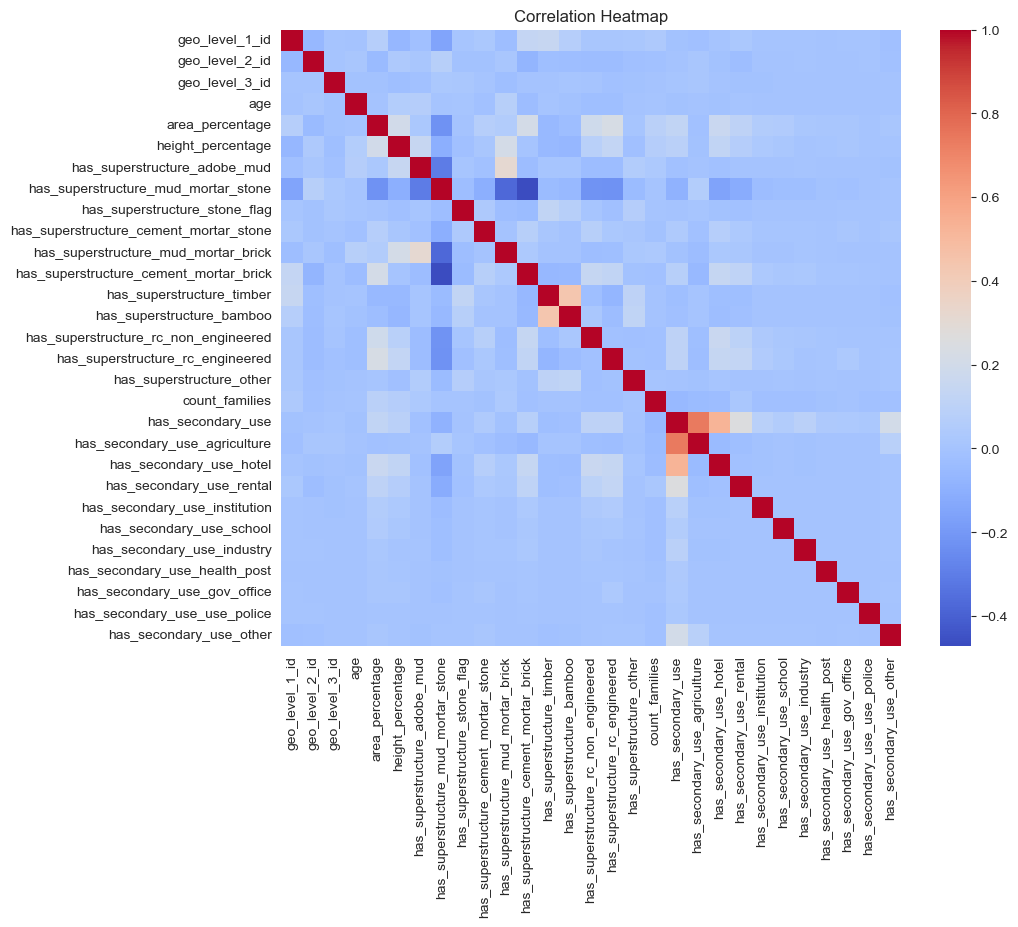

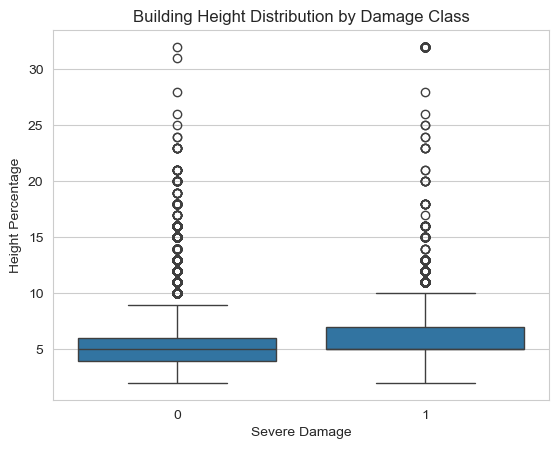

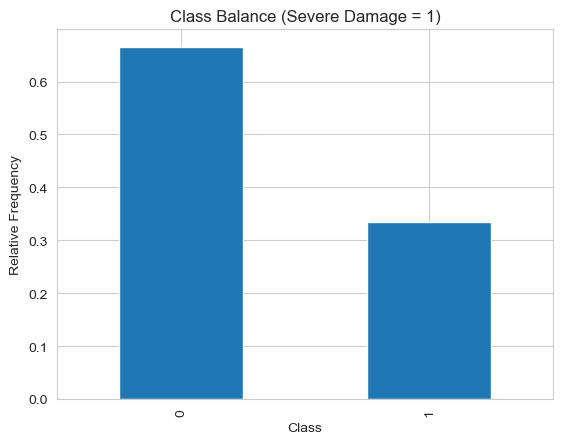

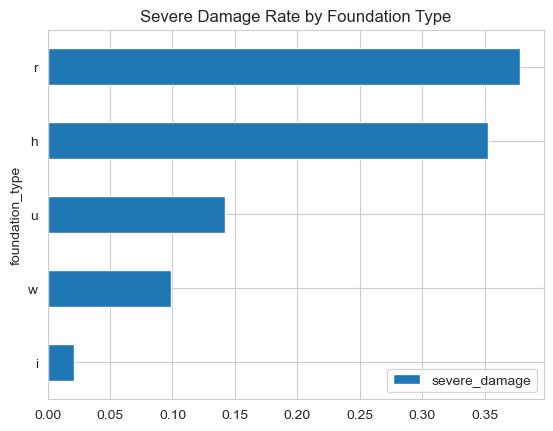

In [9]:
# Correlation heatmap (numeric features only)
numeric_cols = df.select_dtypes("number").drop(columns="severe_damage").columns
correlation = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplot: height vs severe damage
sns.boxplot(x="severe_damage", y="height_percentage", data=df)
plt.xlabel("Severe Damage")
plt.ylabel("Height Percentage")
plt.title("Building Height Distribution by Damage Class")
plt.show()

# Class balance
df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar", xlabel="Class", ylabel="Relative Frequency",
    title="Class Balance (Severe Damage = 1)"
)
plt.show()

# Foundation type pivot (example categorical insight)
foundation_pivot = pd.pivot_table(
    df, index="foundation_type", values="severe_damage", aggfunc="mean"
).sort_values(by="severe_damage")
foundation_pivot.plot(kind="barh")
plt.title("Severe Damage Rate by Foundation Type")
plt.show()

The dataset exhibits clear class imbalance, with severe damage (grade 3) representing the minority class. This is realistic for earthquake damage data, where most buildings suffer only light to moderate damage while a smaller portion collapses or becomes uninhabitable. Building height (`height_percentage`) emerges as a strong signal, with taller structures showing higher median values in the severe damage group - consistent with increased seismic vulnerability due to higher center of mass and greater resonance effects during ground shaking.

The pivot table and bar chart for **foundation_type** reveal even more actionable insights. Severe damage rates vary dramatically across foundation categories (labeled as `i`, `w`, `u`, `h`, and `r` in the data):

- Foundation type `r` has the highest severe damage rate (clearly the tallest bar), followed closely by `h`.
- Types `u` and `w` show moderate risk.
- Foundation type `i` has by far the lowest severe damage rate (very short bar).

## 4: Building the Logistic Regression Model

In [11]:
target = "severe_damage"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

# Model pipeline
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=1000)
)
model.fit(X_train, y_train)

Baseline Accuracy: 0.6654


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('onehotencoder', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,"['land_surface_condition', 'foundation_type', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


### Model Evaluation & Interpretation

Training Accuracy: 0.6681
Test Accuracy: 0.667


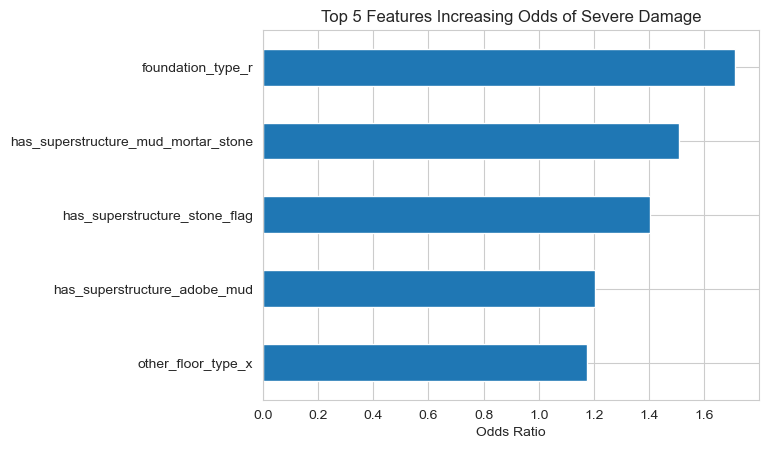

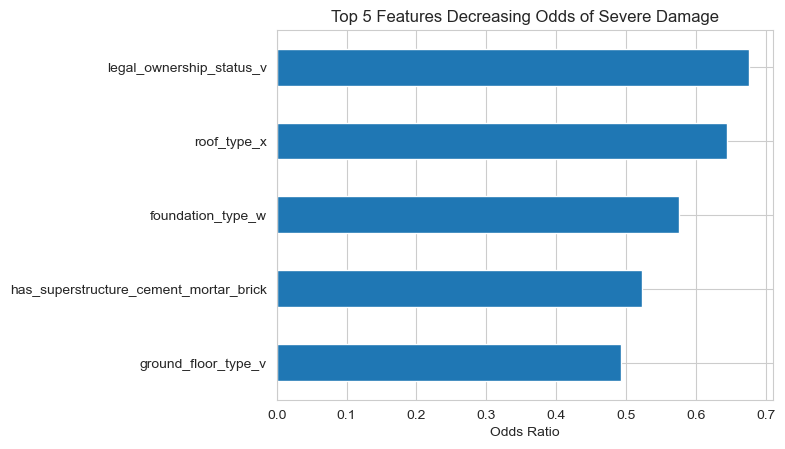

In [12]:
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = model.score(X_test, y_test)
print("Training Accuracy:", round(acc_train, 4))
print("Test Accuracy:", round(acc_test, 4))

# Odds ratios
encoder = model.named_steps["onehotencoder"]
features = encoder.get_feature_names()
importances = model.named_steps["logisticregression"].coef_[0]
odds_ratios = pd.Series(np.exp(importances), index=features).sort_values()

# Top 5 risk-increasing and risk-decreasing features
odds_ratios.tail().plot(kind="barh", title="Top 5 Features Increasing Odds of Severe Damage")
plt.xlabel("Odds Ratio")
plt.show()

odds_ratios.head().plot(kind="barh", title="Top 5 Features Decreasing Odds of Severe Damage")
plt.xlabel("Odds Ratio")
plt.show()

As the logistic regression model hasn't beaten the baseline model much, 0.6681 and 0.6654  respectively, let's explore additional models for improved results.

In [14]:
# === Model Comparison ===
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline (majority class)
baseline_acc = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {baseline_acc:.4f}")

# 1. Logistic Regression (already trained)
log_acc_train = accuracy_score(y_train, model.predict(X_train))
log_acc_test = accuracy_score(y_test, model.predict(X_test))
log_f1_test = f1_score(y_test, model.predict(X_test), average='binary')

# 2. Decision Tree
tree = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    DecisionTreeClassifier(max_depth=10, random_state=42)   # limit depth to prevent overfitting
)
tree.fit(X_train, y_train)

tree_acc_train = accuracy_score(y_train, tree.predict(X_train))
tree_acc_test = accuracy_score(y_test, tree.predict(X_test))
tree_f1_test = f1_score(y_test, tree.predict(X_test), average='binary')

# 3. Random Forest
forest = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced'   # helps with the mild imbalance
    )
)
forest.fit(X_train, y_train)

forest_acc_train = accuracy_score(y_train, forest.predict(X_train))
forest_acc_test = accuracy_score(y_test, forest.predict(X_test))
forest_f1_test = f1_score(y_test, forest.predict(X_test), average='binary')

# Create comparison table
results = pd.DataFrame({
    "Model": ["Baseline (Majority Class)", "Logistic Regression", "Decision Tree", "Random Forest"],
    "Train Accuracy": [baseline_acc, log_acc_train, tree_acc_train, forest_acc_train],
    "Test Accuracy": [None, log_acc_test, tree_acc_test, forest_acc_test],
    "Test F1 Score": [None, log_f1_test, tree_f1_test, forest_f1_test]
})

print("\nModel Comparison:")
print(results.round(4))

Baseline Accuracy: 0.6654

Model Comparison:
                       Model  Train Accuracy  Test Accuracy  Test F1 Score
0  Baseline (Majority Class)          0.6654            NaN            NaN
1        Logistic Regression          0.6681         0.6670         0.1909
2              Decision Tree          0.7700         0.7655         0.6012
3              Random Forest          0.6726         0.6652         0.6173


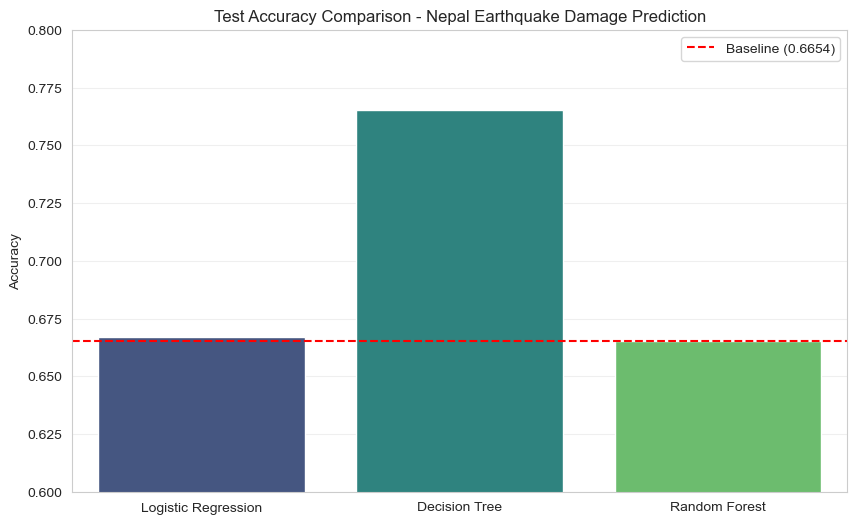

In [15]:
# Bar chart comparison (Test Accuracy)
plt.figure(figsize=(10, 6))
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [log_acc_test, tree_acc_test, forest_acc_test]

sns.barplot(x=models, y=accuracies, palette="viridis")
plt.axhline(y=baseline_acc, color='red', linestyle='--', label=f'Baseline ({baseline_acc:.4f})')
plt.title("Test Accuracy Comparison - Nepal Earthquake Damage Prediction")
plt.ylabel("Accuracy")
plt.ylim(0.6, 0.8)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

The initial Logistic Regression model showed only marginal improvement over the baseline accuracy (0.6670 vs 0.6654 on the test set), with a very low F1 score of 0.1909. This indicates that a purely linear model struggled to capture the complex, non-linear relationships between building characteristics and severe damage outcomes.

Moving to tree-based models produced significantly better results. The **Decision Tree** delivered the strongest performance with a test accuracy of **0.7655** and an F1 score of 0.6012 - a substantial improvement over both the baseline and logistic regression. This jump highlights the presence of important feature interactions (for example, how certain foundation types behave differently at greater building heights) that linear models cannot easily learn.

Interestingly, the Random Forest achieved a competitive F1 score (0.6173) but lower overall accuracy than the Decision Tree in this run. This suggests that while ensemble methods help with generalization and imbalance, a well-pruned single Decision Tree was particularly effective for this dataset and task.

This model iteration process demonstrates a key data science principle: starting with a simple, highly interpretable model (Logistic Regression) to understand baseline performance and feature importance through odds ratios, then progressing to more flexible algorithms when predictive power is the priority. For real-world deployment in disaster risk reduction in Ramechhap district, the Decision Tree offers a good balance between performance and explainability, allowing engineers and policymakers to trace predictions back to specific building attributes like foundation type and height.

## Final Conclusion

Starting from raw CSV files, I built a relational SQLite database from scratch, performed thoughtful data wrangling (removing multicollinear and high-cardinality features), and conducted EDA that revealed important patterns - most notably that foundation type and building height strongly influence damage outcomes. Foundation type `r` showed the highest severe damage rate, while type `i` proved significantly more resilient.

Model iteration highlighted a key lesson in machine learning: while logistic regression offered excellent interpretability through odds ratios, it only marginally outperformed the baseline (0.6670 test accuracy). Tree-based models captured the non-linear interactions much better. The **Decision Tree** achieved the highest test accuracy (0.7655), followed by the Random Forest.